### Скачивание данных

In [2]:
!mkdir -p data/images

# !wget -O /tmp/isic2020_train.zip https://isic-archive.s3.amazonaws.com/challenges/2020/ISIC_2020_Training_JPEG.zip
# !unzip -q -j /tmp/isic2020_train.zip "*.jpg" -d data/images
# !rm /tmp/isic2020_train.zip

# !wget -O /tmp/isic2019_train.zip https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_Input.zip
# !unzip -q -j /tmp/isic2019_train.zip "*.jpg" -d data/images
# !rm /tmp/isic2019_train.zip

!wget -O /tmp/isic2019_test.zip https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_Input.zip
!unzip -q -n -j /tmp/isic2019_test.zip "*.jpg" -d data/images
!rm /tmp/isic2019_test.zip

--2026-06-14 13:53:58--  https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_Input.zip
Resolving isic-archive.s3.amazonaws.com (isic-archive.s3.amazonaws.com)... 16.15.212.114, 16.15.223.28, 54.231.204.89, ...
Connecting to isic-archive.s3.amazonaws.com (isic-archive.s3.amazonaws.com)|16.15.212.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3823247963 (3.6G) [application/zip]
Saving to: ‘/tmp/isic2019_test.zip’

/tmp/isic2019_test. 100%[===================>]   3.56G  46.5MB/s    in 79s     

2026-06-14 13:55:17 (46.4 MB/s) - ‘/tmp/isic2019_test.zip’ saved [3823247963/3823247963]



In [3]:
!wget https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_GroundTruth.csv
!wget https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_GroundTruth.csv
!wget https://isic-archive.s3.amazonaws.com/challenges/2020/ISIC_2020_Training_GroundTruth.csv

--2026-06-14 13:56:08--  https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Training_GroundTruth.csv
Resolving isic-archive.s3.amazonaws.com (isic-archive.s3.amazonaws.com)... 52.217.201.73, 16.15.183.238, 16.15.183.170, ...
Connecting to isic-archive.s3.amazonaws.com (isic-archive.s3.amazonaws.com)|52.217.201.73|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1291479 (1.2M) [text/csv]
Saving to: ‘ISIC_2019_Training_GroundTruth.csv’

ISIC_2019_Training_ 100%[===================>]   1.23M  3.32MB/s    in 0.4s    

2026-06-14 13:56:09 (3.32 MB/s) - ‘ISIC_2019_Training_GroundTruth.csv’ saved [1291479/1291479]

--2026-06-14 13:56:09--  https://isic-archive.s3.amazonaws.com/challenges/2019/ISIC_2019_Test_GroundTruth.csv
Resolving isic-archive.s3.amazonaws.com (isic-archive.s3.amazonaws.com)... 16.15.214.112, 16.182.33.81, 52.217.68.100, ...
Connecting to isic-archive.s3.amazonaws.com (isic-archive.s3.amazonaws.com)|16.15.214.112|:443... connected.
HTTP

In [441]:
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as v2
import torch
from PIL import Image
from sklearn.model_selection import train_test_split

In [5]:
target2019 = pd.read_csv('ISIC_2019_Training_GroundTruth.csv')
target2019test = pd.read_csv('ISIC_2019_Test_GroundTruth.csv')
target2020 = pd.read_csv('ISIC_2020_Training_GroundTruth.csv')

In [6]:
target2020 = target2020[['image_name', 'target']].rename(columns={'image_name' : 'image'})
target2020['target'] = target2020['target'].astype('float64')
target2019 = target2019[['MEL', 'image']].rename(columns={'MEL' : 'target'})
target2019test = target2019test[['MEL', 'image']].rename(columns={'MEL' : 'target'})

In [7]:
labels = pd.concat([target2020, target2019, target2019test], axis=0)
labels = target2019test

### Класс датасета

In [392]:
class ISICDataset(Dataset):
    def __init__(self, root, labels, transforms):
        super().__init__()
        self.transforms = transforms
        self.files = [root + '/' + fname + '.jpg' for fname in labels['image'].tolist()]
        self.targets = labels['target'].tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        fname = self.files[index]
        with Image.open(fname) as im:
            im = im.convert('RGB')
        
        if self.transforms:
            im = self.transforms(im)
        
        return im, self.targets[index]

In [ ]:
transforms = v2.Compose([
    v2.Resize((256, 256)),
    v2.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.9, 1.1), interpolation=v2.InterpolationMode.BILINEAR),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=180, interpolation=v2.InterpolationMode.BILINEAR, fill=0),
    v2.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.03),
    v2.RandomApply([v2.GaussianBlur(kernel_size=3, sigma=(0.1, 0.8))], p=0.2),
    v2.RandomErasing(p=0.3, scale=(0.02, 0.05), ratio=(0.5, 2)),
    
])
ds = ISICDataset('data/images', labels, transforms)

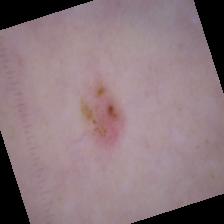

In [ ]:
train_loader = DataLoader